In [2]:
import numpy as np
import control as ct
import sympy as sp
import matplotlib.pyplot as plt

# Root locus technics

## Introduction
The stability and transient performance of a closed-loop control system depend on the locations of the closed-loop roots of its characteristic equation in the s-plane. Adjusting system parameters may be necessary to achieve desired root locations. The root locus method, introduced by Evans in 1948, allows engineers to visualize how these roots change as parameters vary. This graphical technique offers insights into the sensitivity of the roots and can be effectively used with the Routh–Hurwitz criterion.

By providing a graphical representation, the root locus method helps engineers assess the stability and performance of both single-loop and multiloop systems. If the root locations are not satisfactory, necessary parameter adjustments can often be identified from the root locus.

## Root locus concept

The dynamic performance of a closed-loop control system is described by the closed-loop transfer function:

$$
H_{cl}(s) = \frac{Y(s)}{R(s)} = \frac{p(s)}{q(s)}
$$

Where $p$, and $q$ are polynomial in $s$.

The characteristic equation for the closed-loop system is given by:
$$
q(s) = 1+ K P(s) = 0
$$

Where $K$ is a variable parameter $(0\leq K\leq \infty)$ of the closed-loop system.

Since the characteristic polynomial is complex, we can rewrite the characteristic equation in the following form:

$$
\begin{cases}
\left\vert K P(s)\right\vert &= 1\\
\angle{KP(s)} &= 180^{\circ} +k \cdot 360^\circ,\quad\forall\;k=0,\pm1,\pm2,\dots
\end{cases}
$$
The roots of $q(s)$ must satisfy these two equations.

+ **Definition:**

  > <p style="color:darkblue;font-weight:600;font-size:20;">The root locus is the path of the roots of the characteristic equation traced out in the s-plane as a system parameter varies from zero to infinity.</p>

+ **Example: Second order system**

  Let's consider a 2nd-order closed-loop system described by the following transfer function:

  $$
    H_{cl}(s) = \frac{K\over s(s+2)}{1 + {K\over s(s+2)}}
  $$

  The root locus of this system is given by:

  
  ![Roots locus](pics/cap34.png)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


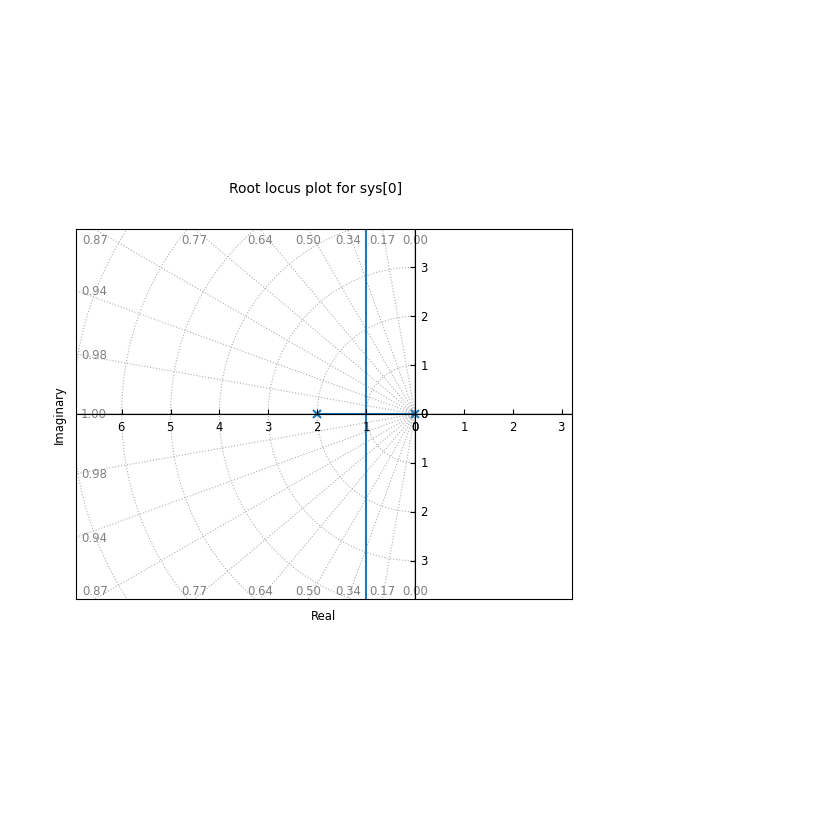

In [3]:
# run-python
zs,ps,k = [],[0,-2],1
P = ct.zpk(zs,ps,k)
ct.root_locus_plot(P)

## Roots locus procedure:
The roots of the characteristic equation of a system provide valuable insight concerning the response of the system. To locate the roots of the characteristic equa-
tion in a graphical manner on the s-plane, we develop an orderly procedure of seven steps that facilitates the rapid sketching of the locus.

|Step number|step description|related equation rule|
|:---:|:---|:---|
|1|**Prepare the roots locus sketch**|                                                                                          |
| |(a) *Write the characteristic equation so that the parameter of interest, $K$, appears as a multiplier.*|$$1 + K P(s) = 0$$|
| |(b) *Factor $P(s)$ in terms of $N$ poles and $M$ zeros.*|$$1 + K \frac{\prod\limits_{i=1}^{M}(s+z_i)}{\prod\limits_{j=1}^{N}s+p_j} = 0$$|
| |(c) *Locate the open-loop poles and zeros of $P(s)$ in the s-plane with selected symbols.*|$\times$ for poles and $\circ$ for zeros.| 
| |                                                                                        |Locus begins at pole and ends at zero|
| |(d) *Determine the number of separate loci.*|$SL = N$ when $N ≥ M$ ; $N$ = number of finite poles, $M$ = of finite zeros.|
| |(e) *The root loci are symmetrical with respect to the horizontal real axis.*||
|2|**Locate the segments of the real axis that are root loci.**|Locus lies to the left of an odd number of poles and zeros.|
|3|**The loci proceed to the zeros at infinity along asymptotes centered at $\sigma_A$ and with angles $\phi_A$.**|$$\sigma_A = \frac{\sum_j (-p_j) -\sum_i (-z_i)}{N-M}$$ $$\phi_A = \frac{2k+1}{N-M}\cdot 180^\circ,\quad \forall\; k=0,1,\dots N-M-1$$|
|4|**Determine the points at which the locus crosses the imaginary axis (if it does so).**|Use Routh–Hurwitz criterion.|
|5|**Determine the breakaway point on the real axis (if any).**|Set $K=P(s)$ and calculate $s\vert\frac{dP}{ds}=0$ or use graphical method to find the maximum of $P(s)$| 
|6|**Determine the angle of locus departure from complex poles and the angle of locus arrival at complex zeros using the phase criterion.**|$$\angle{P(s)}=180^\circ+k\cdot360^\circ\text{ at } s=p_j \text{ or } z_i$$|
|7|**Complete the root locus sketch.**| |

+ ***Example fourth-order closed-loop system:***

  Sketch the root locus for a fourth-order system as $K$ varies for $0 ≤ K < ∞$ when the characteristic equation is given by:

  $$
  1 + {K\over s⁴ +12 s³ + 64 s² +128 s} = 0
  $$

In [4]:
# run-python
s = sp.Symbol('s',complex=True)
K = sp.Symbol('K',real=True)
P = 1 / (s**4 + 12*s**3 + 64*s**2 +128*s)
L = K * P
H = sp.simplify(1 / (1 + L))
H

s*(s**3 + 12*s**2 + 64*s + 128)/(K + s**4 + 12*s**3 + 64*s**2 + 128*s)

In [5]:
# run-python
# Calcul of roots of the open-loop system 
from functools import reduce
q = sp.denom(P).as_poly()
rs = q.all_roots()
q_fact = 1
_,q_fact_list = q.factor_list()
for r in rs:
    q_fact *= s-r

q_fact

s*(s + 4)*(s + 4 - 4*I)*(s + 4 + 4*I)

Text(0.5, 1.0, 'Poles-zeros map')

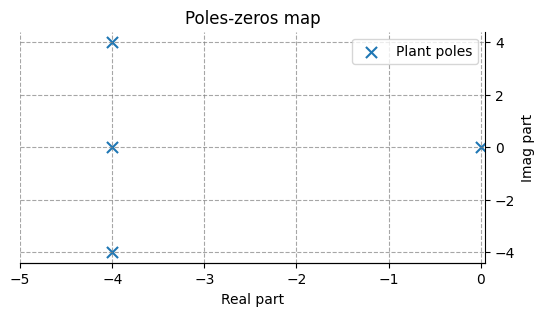

In [6]:
fig, axs = plt.subplots(figsize=(6,3))
rs_re = np.array([sp.re(r) for r in rs],dtype=np.float64)
rs_im = np.array([sp.im(r) for r in rs],dtype=np.float64)
ax = axs.twinx()
for pos in ['left','top','right']:
    axs.spines[pos].set_visible(False)
    if pos != 'right':
        ax.spines[pos].set_visible(False)
axs.yaxis.set_visible(False)
ax.scatter(rs_re,rs_im,marker='x',s=64,label='Plant poles')
axs.grid(True, which='both', axis='x', linestyle='--', color='gray', alpha=0.7)
ax.grid(True, which='both', axis='y', linestyle='--', color='gray', alpha=0.7)
ax.legend()
ax.set_xlim(-5,0.05)
axs.set_xlabel('Real part')
ax.set_ylabel('Imag part')
ax.set_title('Poles-zeros map')

+ **Number of root locus branches: 4**

+ **Real axis segments: 2**

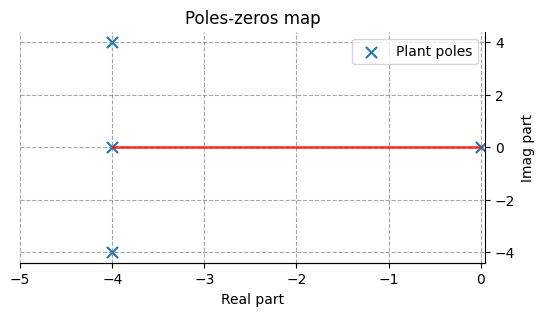

In [7]:
ax.hlines(y=0,xmin=-4,xmax=0,lw=2.0,color='red',alpha=0.75)
fig

+ **Asymptote angles:**
  $$\theta_k = \frac{(2k+1)\pi}{n-m} \quad \forall\;k=0,1,\dots,3$$

+ **Intersection point of asymptotes**
  $$\sigma = \frac{\sum\limits_{k=0}^n p_k}{4}$$

[45.0, 135.0, 225.0, 315.0]
-3


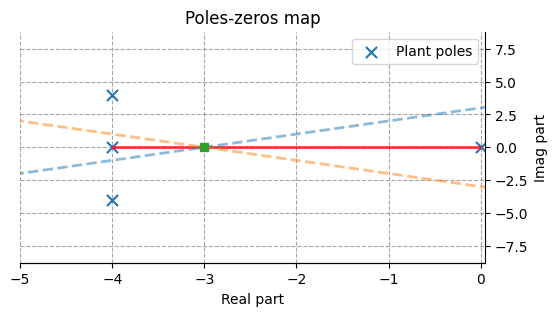

In [8]:
θ = [(2*k+1)*np.pi/4 for k in range(4)]
print([ang*180/np.pi for ang in θ])
σ = sum(rs)/4
print(σ)
x = np.linspace(-8,5,128)
y = (x-σ)*np.tan(θ[0])
ax.plot(x,y,ls='--',lw=2.0,alpha=0.5)
y = np.tan(θ[1])*(x-σ)
ax.plot(x,y,ls='--',lw=2.0,alpha=0.5)
ax.plot([σ],[0],marker='s',ms=6)
fig

+ **Calculate Break-in points/Breakaway:**

  This corresponds to:
  $$
  \dfrac{dK}{ds}=0 \Rightarrow \dfrac{dP}{ds}=0
  $$

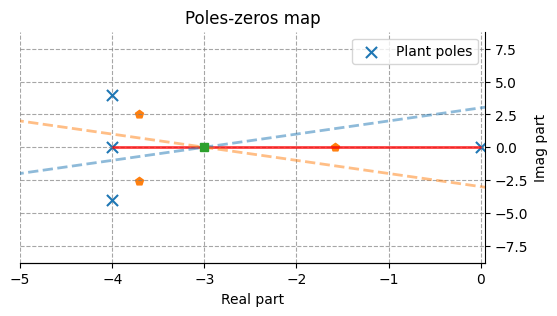

In [9]:
dK = sp.diff(-1/P,s)
bps = sp.solve(dK,s)
bps = np.array([sp.N(bp) for bp in bps],dtype=np.complex64)
ax.scatter(bps.real,bps.imag,marker='p',s=36)
fig

+ **Imaginary Axis Crossings:**
  $$
  \text{imag crossing} = \{p(K) \vert \sigma=0\}
  $$
  With $p(K)$ is the poles of the closed-loop feedback system.

In [10]:
Eq = sp.Eq(q.as_expr() + K,0) 
Eq

Eq(K + s**4 + 12*s**3 + 64*s**2 + 128*s, 0)

+ **Routh array:**
  |Monone| | | | 
  |:---|:---:|:---:|:---:|
  |$s^4$| $1$ | $64$ | $K$ |
  |$s^3$| $12$ | $128$ | $0$ |
  |$s^2$| $53.33$ | $K$ | $0$ |
  |$s$| $128 - \frac{12K}{53.33}$ | $0$ | $0$ |
  |$1$| $K$ | $0$ | $0$ |

In [11]:
for iac in sp.solve(Eq.subs(K,53.33333333336*128/12)):
    display(round(iac,ndigits=2))

-6.0 - 4.16*I

-6.0 + 4.16*I

-3.27*I

3.27*I

+ **Departure and arrival angles:**
  $$\angle_{dep} = 180^{\circ} - (\sum \text{angles to other poles} - \sum \text{angles to zeros})$$

  + Pole $p_1 = 0$
  $$
    \begin{aligned}
        \angle_{dep}(p_1) &= 180^{\circ} - \left(\angle_{dep}p_2 - \angle_{dep}p_3 - \angle_{dep}p_4 \right)\\
        & = 0
        \end{aligned}
    $$
 
  + Pole $p_2 = -4$
    $$
    \begin{aligned}
        \angle_{dep}(p_2) &= 180^{\circ} - \left(\angle_{dep}p_1 - \angle_{dep}p_3 - \angle_{dep}p_4 \right)\\
            & = 180 
    \end{aligned} 
    $$
 
  + Pole $p_3 = -4-4\jmath$
    $$
    \begin{aligned}
        \angle_{dep}(p_2) &= 180^{\circ} - \left(\angle_{dep}p_1 - \angle_{dep}p_2 - \angle_{dep}p_4 \right)\\
            & = 225 
    \end{aligned} 
    $$

  + Pole $p_4 = -4+4\jmath$
    $$
    \begin{aligned}
        \angle_{dep}(p_2) &= 180^{\circ} - \left(\angle_{dep}p_1 - \angle_{dep}p_2 - \angle_{dep}p_4 \right)\\
            & = 135
    \end{aligned} 
    $$

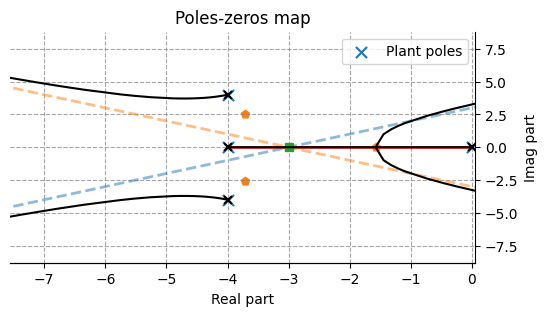

In [12]:
s = ct.TransferFunction.s
P = 1 / (s**4 +12*s**3+64*s**2+128*s)
ct.root_locus_plot(P,ax=ax,color='k')
fig

***Exercice:***
Tracer le root-locus pour le système décrit par la fonction de transfert en boucle ouverte suivante:
$$
L(s) = K \frac{s+2}{s^3 + 4s^2 + 3s}
$$

## Parameter design by the root locus method
The root locus method was initially developed to determine the trajectory of system poles as the gain $K$ varies from $0$ to $\infty$. Nevertheless, this method can also be used to explore the effects of other parameters since it is concerned with the characteristic equation:
$$
q(s) = 1 + L(s) = 0
$$
With $L(s)$ the open-loop transfer function.

The characteristic equation of a dynamic system can be written as:
$$
q(s) = \sum\limits_{k=0}^{n} a_{k} s^k = 0
$$

Hence, the effect of varying $0\leq a_i<\infty$ may be ascertained from the root locus equation:

$$
1 + \frac{a_i s^i}{\sum\limits_{k=0,k\ne i}^{n}a_k s^k}=0
$$

+ ***Example:***

  Let's consider a 3rd-order characteristic equation with two parameters:
  $$
    s^3 + s^2 + \beta s + \alpha = 0
  $$
  We can begin by isolating the $\beta$ parameter:
  $$
  1 + \frac{\beta s}{s^3 + s^2 + \alpha}=0
  $$
  The effect of varying this parameter on the system depends on the value taken by $\alpha$, so we must investigate firstly the impact of the latter before dealing with $\beta$:
  $$
    1 + \frac{\alpha}{s^2(s+1)}=0
  $$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


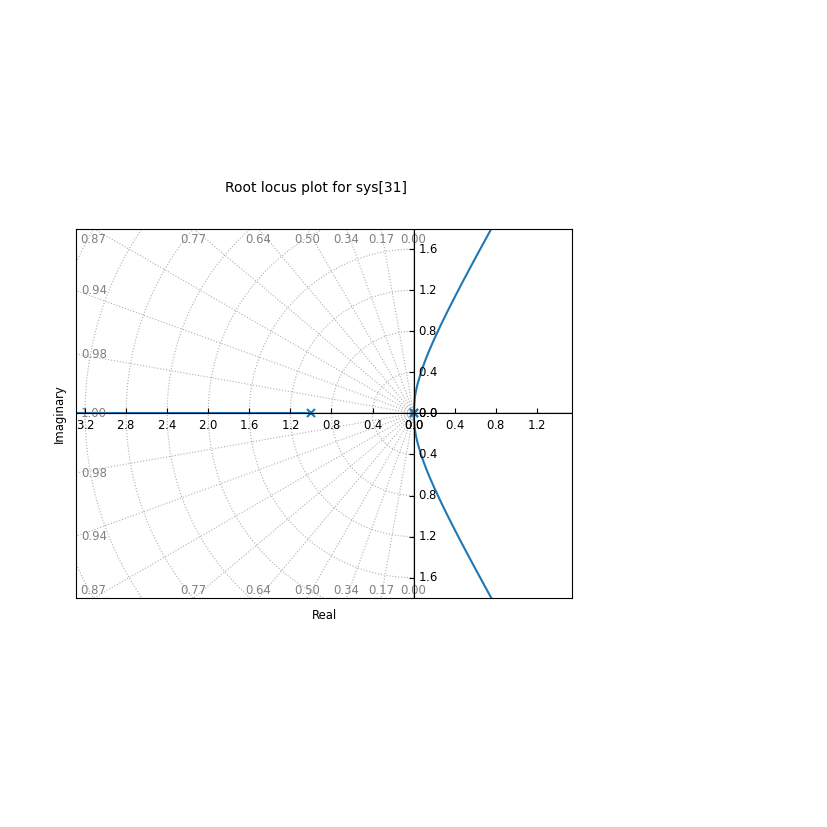

In [13]:
L1 = 1/(s**2*(s+1))
ct.root_locus_plot(L1)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


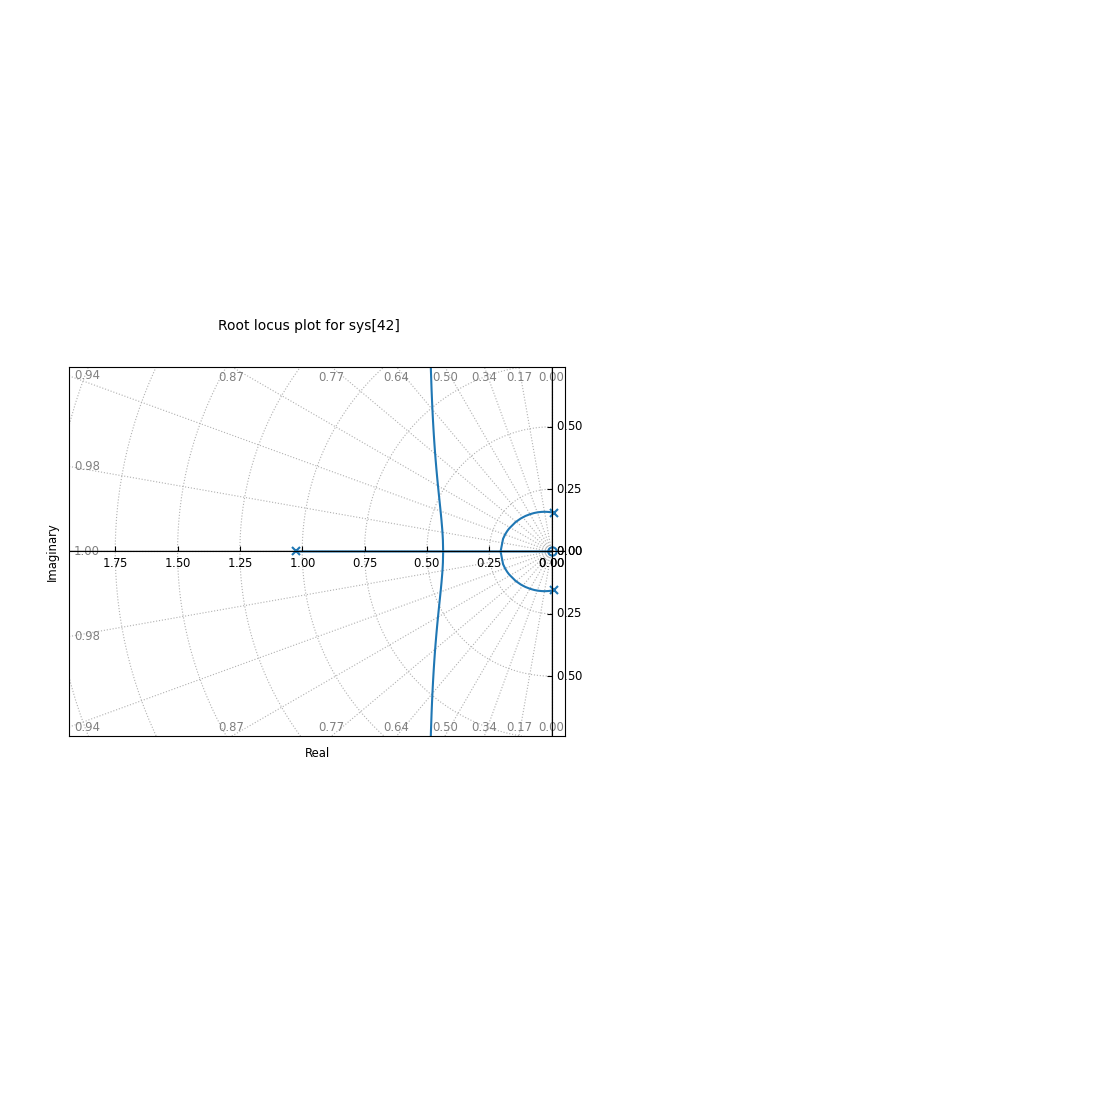

In [14]:
rl_α_map = ct.root_locus_map(L1) 
α = rl_α_map.gains[2]
L2 = s/(s**3 + s**2 + α)
ct.root_locus_plot(L2)

+ ***Exercice: Wlding head control***

    A welding head for an auto body requires an accurate control system for position ing the welding head. The feedback control system is to be designed to satisfy 
    the following specifications:
    1. Steady-state error for a ramp input is ess ≤ 35% of input slope
    2. Damping ratio of dominant roots is ζ ≥ 0.707
    3. Settling time to within 2% of the final value is Ts ≤ 3 s.
    
    The structure of the feedback control system is shown in the following figure:
  
  ![](pics/diag80.svg)

  Do the system analysis and conception using the root locus method.